In [1]:
# This program predicts the price of Bitcoin for the next 5 days
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load and store the data
df = pd.read_csv('BTC-USD_daily_2021.csv')

In [4]:
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-01,28994.009766,29600.626953,28803.585938,29374.152344,29374.152344,40730301359
1,2021-01-02,29376.455078,33155.117188,29091.181641,32127.267578,32127.267578,67865420765
2,2021-01-03,32129.408203,34608.558594,32052.316406,32782.023438,32782.023438,78665235202
3,2021-01-04,32810.949219,33440.218750,28722.755859,31971.914063,31971.914063,81163475344
4,2021-01-05,31977.041016,34437.589844,30221.187500,33992.429688,33992.429688,67547324782


In [5]:
prediction_days = 5

In [6]:
# Remvove the Date column
df[str(prediction_days)+'_Day_Price_Forecast'] = df[["Close"]].shift(-prediction_days)
df = df[['Close', str(prediction_days)+'_Day_Price_Forecast']]

In [7]:
df.tail(7)

,Close,5_Day_Price_Forecast
315,64155.941406,60368.011719
316,64469.527344,58873.941406
317,65466.839844,NaN
318,63557.871094,NaN
319,60161.246094,NaN
320,60368.011719,NaN
321,58873.941406,NaN


In [8]:
# Create the independent data set
# Convert the df to numpy array and drop prediction column
X = np.array(df[['Close']])

# Remove the last 5 rows
X = X[:len(df) - prediction_days]

X


array([[29374.152344],
       [32127.267578],
       [32782.023438],
       [31971.914063],
       [33992.429688],
       [36824.363281],
       [39371.042969],
       [40797.609375],
       [40254.546875],
       [38356.441406],
       [35566.65625 ],
       [33922.960938],
       [37316.359375],
       [39187.328125],
       [36825.367188],
       [36178.140625],
       [35791.277344],
       [36630.074219],
       [36069.804688],
       [35547.75    ],
       [30825.699219],
       [33005.761719],
       [32067.642578],
       [32289.378906],
       [32366.392578],
       [32569.849609],
       [30432.546875],
       [31649.605469],
       [34316.386719],
       [34269.523438],
       [33114.359375],
       [33537.175781],
       [35510.289063],
       [37472.089844],
       [36926.066406],
       [38144.308594],
       [39266.011719],
       [38903.441406],
       [46196.464844],
       [46481.105469],
       [44918.183594],
       [47909.332031],
       [47504.851563],
       [471

In [9]:
# Create the dependent dataset
# Convert the df to numpy array

y = np.array(df[str(prediction_days)+'_Day_Price_Forecast'])[:-prediction_days]
y

array([36824.363281, 39371.042969, 40797.609375, 40254.546875,
       38356.441406, 35566.65625 , 33922.960938, 37316.359375,
       39187.328125, 36825.367188, 36178.140625, 35791.277344,
       36630.074219, 36069.804688, 35547.75    , 30825.699219,
       33005.761719, 32067.642578, 32289.378906, 32366.392578,
       32569.849609, 30432.546875, 31649.605469, 34316.386719,
       34269.523438, 33114.359375, 33537.175781, 35510.289063,
       37472.089844, 36926.066406, 38144.308594, 39266.011719,
       38903.441406, 46196.464844, 46481.105469, 44918.183594,
       47909.332031, 47504.851563, 47105.515625, 48717.289063,
       47945.058594, 49199.871094, 52149.007813, 51679.796875,
       55888.132813, 56099.519531, 57539.945313, 54207.320313,
       48824.425781, 49705.332031, 47093.851563, 46339.761719,
       46188.453125, 45137.769531, 49631.242188, 48378.988281,
       50538.242188, 48561.167969, 48927.304688, 48912.382813,
       51206.691406, 52246.523438, 54824.117188, 56008.

In [10]:
# Split the data into 80% training and 20% testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [11]:
from sklearn.linear_model import LinearRegression

# Create and train the SVM by Regression using radial basis function

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [12]:
# Test the model
svm_prediction = model.predict(x_test)
print(svm_prediction)
print(y_test)


[45407.56293324 46163.74396806 45198.39845551 47066.8158704
 48017.8242967  47673.00418211 47220.39029332 48107.33597224
 47213.98436148 43338.88216697 41452.29576042 43980.02719516
 45138.75370941 43335.327886   43227.26676996 43658.91485566
 42805.34240308 41751.38321037 42216.26399569 44169.89161734
 47965.69940921 47609.94225364 48038.53646782 48839.58644698
 50947.09696384 54322.25540579 52957.44227607 53099.46614242
 53977.22621519 53804.6842006  56185.33968516 54918.56576386
 56111.90624721 56042.08535866 59790.84433845 59175.08997175
 59755.4557627  60170.00765219 62131.86804517 63650.56407011
 60331.53722199 58999.67916831 59615.06679692 59209.00816524
 61059.49993781 58711.46706542 57060.66283011 58938.14588966
 60347.14932522 60049.58366972 59549.55765801 59273.56104032
 61223.20937535 60998.27513057 59666.4959088  59379.96669056
 59732.52259427 61311.46659827 65031.6336656  64509.56219911
 62775.2340698  62735.51317831 62038.81579764 62313.96583214]
[47783.359375 47267.5195

In [13]:
model.score(x_test, y_test)

0.729738591015471

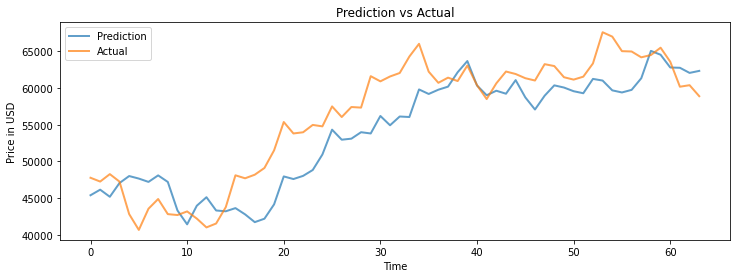

In [14]:
plt.figure(figsize=(12,4))
plt.plot(svm_prediction, label='Prediction', lw=2, alpha=.7)
plt.plot(y_test, label='Actual', lw=2, alpha=.7)
plt.title('Prediction vs Actual')
plt.ylabel('Price in USD')
plt.xlabel('Time')
plt.legend()
plt.show()

In [16]:
balance = 1000
amount = 0
position = False

for i in range(59):
    print("{}: ".format(i))
    if position and x_test[i][0] > svm_prediction[i + 5]:
        print("sell price {}".format(x_test[i][0]))
        position = False
        balance = amount * x_test[i][0]
        amount = 0
        print(balance)
    if not position and x_test[i][0] < svm_prediction[i + 5]:
        print("buy {}".format(x_test[i][0]))
        position = True
        amount = balance / x_test[i][0]
        balance = 0

0: 
buy 45201.457031
1: 
2: 
3: 
4: 
sell price 48176.347656
1065.8140427411392
5: 
6: 
7: 
8: 
9: 
buy 42843.800781
10: 
11: 
sell price 43574.507813
1083.9916507413302
12: 
13: 
14: 
buy 42716.59375
15: 
16: 
17: 
18: 
19: 
20: 
21: 
22: 
23: 
24: 
25: 
26: 
27: 
28: 
29: 
30: 
31: 
32: 
33: 
34: 
35: 
sell price 60892.179688
1545.2218583611389
36: 
37: 
38: 
39: 
40: 
41: 
42: 
43: 
44: 
45: 
46: 
buy 58482.386719
47: 
48: 
sell price 62227.964844
1644.1875387250182
49: 
50: 
51: 
52: 
53: 
buy 62970.046875
54: 
55: 
56: 
57: 
sell price 63326.988281
1653.5075033895703
58: 
